In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

In [2]:
results = pd.read_csv('results/best_all_shash_nll.csv')

In [3]:
mdt_baselines = [1.3741, 1.4390, 1.4147, 1.4157, 1.3959, 1.3819, 1.3022, 1.4223, 1.4106]
slgt_baselines = [1.3096, 1.3813, 1.3845, 1.3758, 1.3646, 1.3463, 1.1283, 1.0743, 0.9984]

In [4]:
np.mean(mdt_baselines), np.mean(slgt_baselines)

(np.float64(1.3951555555555557), np.float64(1.2625666666666668))

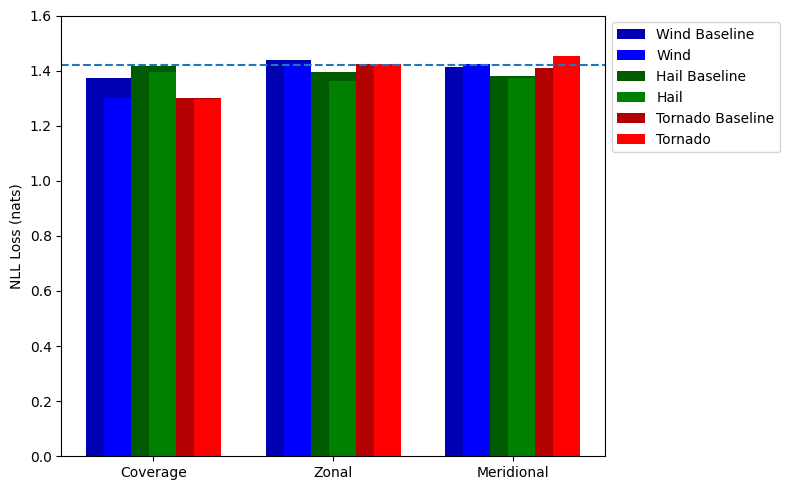

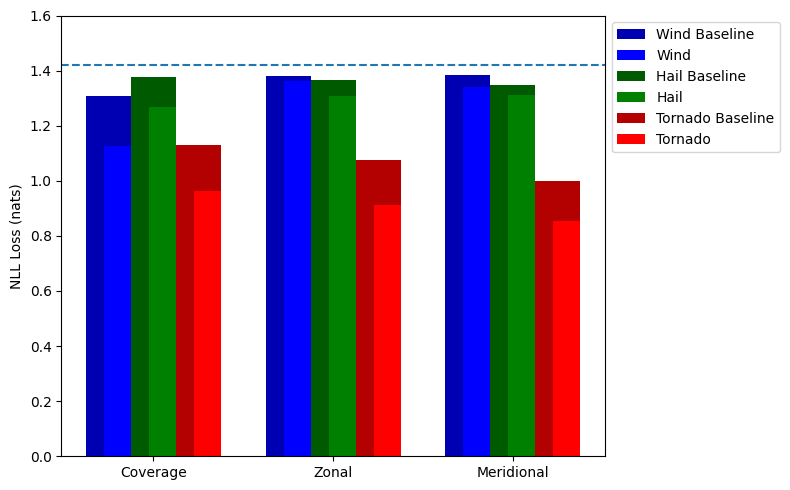

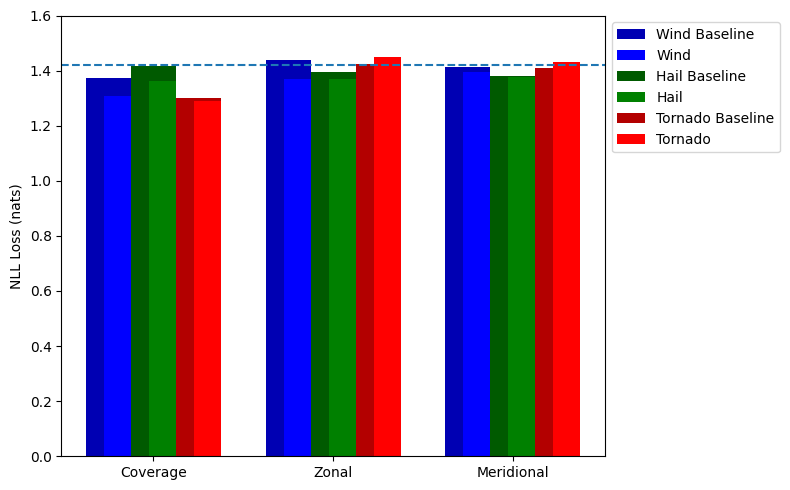

In [7]:
def darker(color, factor=0.7):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb * factor)

for _, row in results.iterrows():
    model = row['model']

    values = row[[str(i) for i in range(9)]].astype(float).values

    values_grouped = np.array([
        [values[0], values[3], values[6]],  # Coverage
        [values[1], values[4], values[7]],  # E-W
        [values[2], values[5], values[8]],  # N-S
    ])

    baseline = slgt_baselines if "slgt" in model else mdt_baselines
    baseline = np.array(baseline)

    baseline_grouped = np.array([
        [baseline[0], baseline[3], baseline[6]],
        [baseline[1], baseline[4], baseline[7]],
        [baseline[2], baseline[5], baseline[8]],
    ])

    groups = ["Coverage", "Zonal", "Meridional"]
    hazards = ["Wind", "Hail", "Tornado"]
    colors = ["blue", "green", "red"]
    baseline_colors = [darker(c) for c in colors]

    fig, ax = plt.subplots(figsize=(8,5))

    x = np.arange(len(groups))
    width = 0.25
    inner_width = width * 0.6

    for i in range(3):
        # baseline (background)
        ax.bar(
            x + (i-1)*width,
            baseline_grouped[:, i],
            width=width,
            color=baseline_colors[i]
        )

        # model (foreground)
        ax.bar(
            x + (i-1)*width + width * .2,
            values_grouped[:, i],
            width=inner_width,
            color=colors[i],
            label=hazards[i] if i == 0 else None
        )

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel("NLL Loss (nats)")
    #ax.set_title("Model NLL Loss Versus Baseline by Hazard and Bias Type", fontsize=16)

    ax.legend(["Wind Baseline", "Wind", "Hail Baseline", "Hail", "Tornado Baseline", "Tornado"], loc="upper left", bbox_to_anchor=(1, 1))

    ax.set_ylim(0, 1.6)
    ax.axhline(1.42, linestyle="--")


    plt.tight_layout()
    plt.savefig('figs/error/best/shash/' + model.replace('/', '_') + '.pdf')
    plt.show()